# 6.4 Machine Learning Part 1
## Table of Contents — Coffee Quality Regression Analysis

### 1. Setup and Imports
- Install scikit-learn
- Import necessary libraries

### 2. Data Cleaning and Exploration
- Clean and prepare dataset
- Visualize key relationships
- Check for outliers and consistency

### 3. Data Prep for Regression Analysis
- 3.1 Data Prep – Flavor vs Total Cup Points
- 3.2 Data Prep – Balance vs Total Cup Points

### 4. Regression Analysis: Predicting Coffee Quality
- 4.1 Regression – Flavor vs Total Cup Points
- 4.2 Regression – Balance vs Total Cup Points

### 5. Performance Improvement After Removing Outliers
- 5.1 Outlier Impact – Flavor vs Total Cup Points
- 5.2 Outlier Impact – Balance vs Total Cup Points


## 1. Setup and Imports

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# File Pathway
path = r"C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee"

In [3]:
# Import Main dataset
df_coffee_m = pd.read_csv(
    r'C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\02_Data\Prepared_Data\Coffee_Datasets_Merged.csv')

## 2. Data Cleaning and Exploration

In [11]:
# Column list
df_coffee_m.columns

Index(['coffee_name', 'total_score', 'roast_level', 'agtron_roast',
       'price_usd', 'quantity_g', 'usd_per_gram', 'roaster_location',
       'roaster_city', 'roaster_region', 'roaster_country', 'coffee_origin',
       'coffee_city', 'coffee_region', 'coffee_country', 'species', 'owner',
       'local_partner', 'harvest_year', 'variety', 'processing_method',
       'aroma', 'flavor', 'aftertaste', 'acidity', 'body', 'balance',
       'uniformity', 'clean_cup', 'sweetness', 'cupper_points',
       'total_cup_points', 'moisture', 'unit_of_measurement',
       'altitude_mean_meters'],
      dtype='object')

In [12]:
# Column inspection
df_coffee_m.head(20)

,coffee_name,total_score,roast_level,agtron_roast,price_usd,quantity_g,usd_per_gram,roaster_location,roaster_city,roaster_region,...,body,balance,uniformity,clean_cup,sweetness,cupper_points,total_cup_points,moisture,unit_of_measurement,altitude_mean_meters
0,colombia finca campo hermosa,94.0,light,82.0,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.58,7.58,10.00,10.00,10.00,7.58,83.17,0.11,m,NaN
1,colombia finca campo hermosa,94.0,light,82.0,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.75,7.50,10.00,10.00,10.00,7.50,83.00,0.00,m,NaN
2,colombia finca campo hermosa,94.0,light,82.0,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.67,7.83,10.00,10.00,10.00,7.58,82.67,0.21,m,NaN
3,colombia finca campo hermosa,94.0,light,82.0,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.67,7.42,10.00,10.00,10.00,7.25,82.08,0.11,m,NaN
4,colombia finca campo hermosa,94.0,light,82.0,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.08,7.42,10.00,10.00,10.00,7.25,80.67,0.18,m,NaN
5,colombia finca campo hermosa,94.0,light,82.0,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.08,7.33,10.00,10.00,10.00,7.33,80.58,0.00,m,NaN
6,colombia finca campo hermosa,94.0,light,82.0,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,8.08,7.58,8.67,8.67,8.67,7.58,80.25,0.10,m,NaN
7,colombia finca campo hermosa,94.0,light,82.0,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.58,7.50,10.00,10.00,10.00,7.25,79.08,0.10,m,NaN
8,colombia finca campo hermosa,94.0,light,82.0,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.67,7.17,8.67,9.33,9.33,7.08,78.00,0.10,m,NaN
9,colombia finca campo hermosa,94.0,light,82.0,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.42,7.67,6.67,6.67,6.67,7.33,72.83,0.00,m,NaN


In [13]:
# Data shape
df_coffee_m.shape

(8877, 35)

In [14]:
# Missing value check
df_coffee_m.isnull().sum().sort_values(ascending=False)

altitude_mean_meters    4114
harvest_year            3857
local_partner           1535
cupper_points           1535
total_cup_points        1535
moisture                1535
owner                   1535
clean_cup               1535
sweetness               1535
uniformity              1535
species                 1535
flavor                  1535
body                    1535
acidity                 1535
aftertaste              1535
processing_method       1535
aroma                   1535
variety                 1535
balance                 1535
unit_of_measurement     1535
roast_level                0
coffee_name                0
total_score                0
coffee_origin              0
coffee_city                0
coffee_region              0
coffee_country             0
usd_per_gram               0
quantity_g                 0
price_usd                  0
agtron_roast               0
roaster_location           0
roaster_city               0
roaster_region             0
roaster_countr

In [15]:
# Check for duplicates
df_coffee_m.duplicated().sum()

np.int64(1)

In [16]:
# Preview Descriptive Stats
df_coffee_m.describe()

,total_score,harvest_year,aroma,flavor,aftertaste,acidity,body,balance,uniformity,clean_cup,sweetness,cupper_points,total_cup_points,moisture,altitude_mean_meters
count,8877.000000,5020.000000,7342.000000,7342.000000,7342.000000,7342.000000,7342.000000,7342.000000,7342.000000,7342.000000,7342.000000,7342.000000,7342.000000,7342.000000,4763.000000
mean,94.518531,2013.633865,7.681132,7.654628,7.568052,7.629154,7.662339,7.713026,9.862911,9.896622,9.879996,7.687694,83.236481,0.078319,1883.594846
std,0.723347,1.368464,0.291425,0.333565,0.355664,0.355753,0.286596,0.294904,0.544729,0.495593,0.493196,0.416670,2.540703,0.055758,7236.690985
min,94.000000,2010.000000,6.500000,6.170000,6.170000,6.500000,6.500000,6.170000,6.670000,5.330000,6.670000,5.420000,69.170000,0.000000,1.000000
25%,94.000000,2013.000000,7.500000,7.420000,7.420000,7.420000,7.500000,7.580000,10.000000,10.000000,10.000000,7.500000,82.330000,0.000000,1600.000000
50%,94.000000,2014.000000,7.670000,7.670000,7.580000,7.580000,7.670000,7.670000,10.000000,10.000000,10.000000,7.580000,83.250000,0.100000,1750.000000
75%,95.000000,2014.000000,7.830000,7.750000,7.750000,7.830000,7.830000,7.830000,10.000000,10.000000,10.000000,7.830000,84.250000,0.110000,1800.000000
max,98.000000,2017.000000,8.580000,8.670000,8.500000,8.500000,8.500000,8.580000,10.000000,10.000000,10.000000,10.000000,89.750000,0.220000,190164.000000


In [17]:
# Create a modeling-ready subset with complete sensory and scoring data
df_model = df_coffee_m.dropna(subset=['total_cup_points', 'aroma', 'flavor', 'aftertaste', 'acidity', 'body', 'balance'])

In [18]:
# Preview how many rows remain
print(f"Original rows: {df_coffee_m.shape[0]}")
print(f"Filtered rows: {df_model.shape[0]}")

Original rows: 8877
Filtered rows: 7342


Filtered the dataset to keep only rows with complete values for total_cup_points and key sensory predictors. This ensures model reliability while maintaining focus on our central scoring target. The resulting subset df_model contains: 7342 rows and down from 8877.

In [20]:
# Check for outliers and save them
for col in ['total_cup_points', 'flavor', 'aroma', 'aftertaste', 'acidity', 'body', 'balance']:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_model[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.savefig(f'C:/Users/Chase/anaconda_projects/Exercise_6_Coffee/A6_Coffee/04_Analysis/Visulazations/Outlier Check/boxplot_{col}.png')
    plt.close()

Boxplots were generated for all key numeric variables to assess distribution and found outlier presence in each. Outliers were retained to preserve the integrity of the original scoring data. Their presence will be considered during model evaluation and interpretation.

In [21]:
# Check for outliers and save them. roast level had to be seperate since it's not numeric
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_model, x='roast_level', y='total_cup_points')
plt.title('Total Cup Points by Roast Level')
plt.tight_layout()
plt.savefig('C:/Users/Chase/anaconda_projects/Exercise_6_Coffee/A6_Coffee/04_Analysis/Visulazations/Outlier Check/boxplot_roast_level_vs_cup_points.png')
plt.close()

## 3. Data Prep for Regression Analysis

### 3.1 Data Prep - Flavor vs Total Cup Points

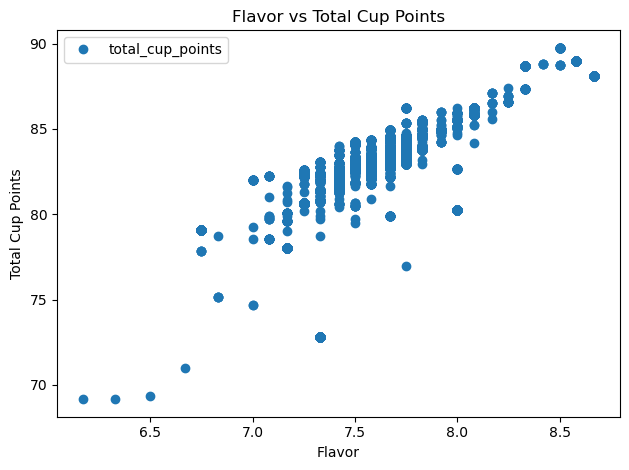

In [25]:
# Create a scatter plot for visual Inspection with a Scatterplot
# Look at the relationship between flavor and total_cup_points

df_model.plot(x='flavor', y='total_cup_points', style='o')  # 'o' creates a scatterplot
plt.title('Flavor vs Total Cup Points')
plt.xlabel('Flavor')
plt.ylabel('Total Cup Points')
plt.tight_layout()
plt.savefig('C:/Users/Chase/anaconda_projects/Exercise_6_Coffee/A6_Coffee/04_Analysis/Visulazations/Outlier Check/scatterplot_flavor_vs_cup_points.png')
plt.show()

In [26]:
# Reshape Variables for Modeling
X = df_model['flavor'].values.reshape(-1, 1)  # Predictor
y = df_model['total_cup_points'].values.reshape(-1, 1)  # Target

In [27]:
# Preview X
print("X (flavor):")
print(X)

X (flavor):
[[7.75]
 [7.58]
 [7.42]
 ...
 [7.42]
 [7.17]
 [7.08]]


In [28]:
# Preview y
print("\ny (total_cup_points):")
print(y)


y (total_cup_points):
[[83.17]
 [83.  ]
 [82.67]
 ...
 [81.92]
 [80.08]
 [78.58]]


In [29]:
# Split data into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

In [30]:
# Print split results
print("X_train:")
print(X_train)

print("\nX_test:")
print(X_test)

print("\ny_train:")
print(y_train)

print("\ny_test:")
print(y_test)

X_train:
[[7.58]
 [7.5 ]
 [7.58]
 ...
 [7.75]
 [8.  ]
 [7.67]]

X_test:
[[8.33]
 [7.67]
 [7.75]
 ...
 [7.75]
 [6.75]
 [8.  ]]

y_train:
[[84.33]
 [82.92]
 [83.42]
 ...
 [83.83]
 [80.25]
 [83.25]]

y_test:
[[87.33]
 [79.92]
 [83.67]
 ...
 [83.08]
 [79.08]
 [85.5 ]]


### 3.2 Data Prep - Balance vs Total Cup Points

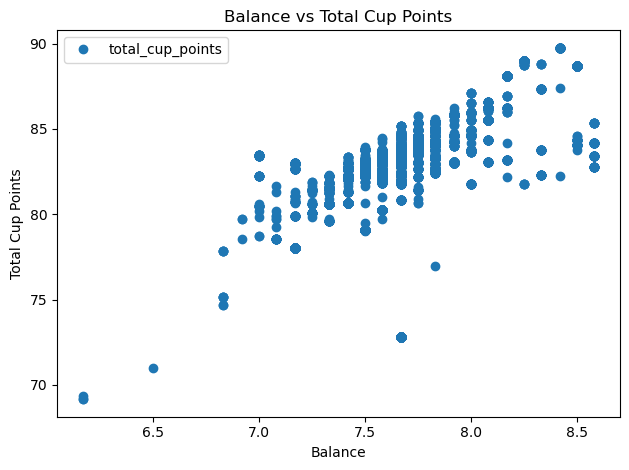

In [47]:
# Visual inspection with a scatterplot
df_model.plot(x='balance', y='total_cup_points', style='o')
plt.title('Balance vs Total Cup Points')
plt.xlabel('Balance')
plt.ylabel('Total Cup Points')
plt.tight_layout()
plt.savefig('C:/Users/Chase/anaconda_projects/Exercise_6_Coffee/A6_Coffee/04_Analysis/Visulazations/Outlier Check/scatterplot_balance_vs_cup_points.png')
plt.show()

In [49]:
# Reshape variables for modeling
X = df_model['balance'].values.reshape(-1, 1)
y = df_model['total_cup_points'].values.reshape(-1, 1)

print("X (balance):")
print(X)

print("\ny (total_cup_points):")
print(y)

X (balance):
[[7.58]
 [7.5 ]
 [7.83]
 ...
 [7.67]
 [7.25]
 [7.08]]

y (total_cup_points):
[[83.17]
 [83.  ]
 [82.67]
 ...
 [81.92]
 [80.08]
 [78.58]]


In [50]:
# Split Data into Training and Test Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

print("X_train:")
print(X_train)

print("\nX_test:")
print(X_test)

print("\ny_train:")
print(y_train)

print("\ny_test:")
print(y_test)

X_train:
[[8.08]
 [7.5 ]
 [8.58]
 ...
 [7.67]
 [7.58]
 [7.83]]

X_test:
[[8.33]
 [7.17]
 [7.67]
 ...
 [7.92]
 [7.5 ]
 [8.08]]

y_train:
[[84.33]
 [82.92]
 [83.42]
 ...
 [83.83]
 [80.25]
 [83.25]]

y_test:
[[87.33]
 [79.92]
 [83.67]
 ...
 [83.08]
 [79.08]
 [85.5 ]]


## 4. Regression Analysis: Predicting Coffee Quality

### 4.1 Regression - Flavor vs Total Cup Points

In [31]:
# Create and fit the model
regression = LinearRegression()
regression.fit(X_train, y_train)

LinearRegression()

In [32]:
# Predict on the test set
y_predicted = regression.predict(X_test)

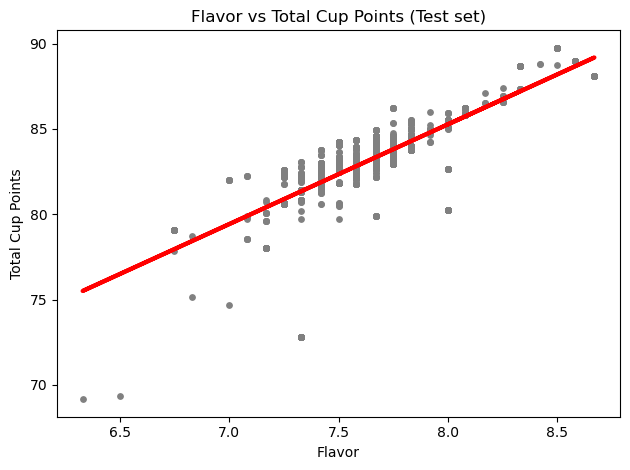

In [33]:
# Visualize the Regression Line (Test Set)
plt.scatter(X_test, y_test, color='gray', s=15)
plt.plot(X_test, y_predicted, color='red', linewidth=3)
plt.title('Flavor vs Total Cup Points (Test set)')
plt.xlabel('Flavor')
plt.ylabel('Total Cup Points')
plt.tight_layout()
plt.savefig('C:/Users/Chase/anaconda_projects/Exercise_6_Coffee/A6_Coffee/04_Analysis/Visulazations/Outlier Check/regression_test_flavor_vs_cup_points.png')
plt.show()

In [37]:
# Evaluate model performance (test set)
rmse = mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)

print('Slope:', regression.coef_)
print('Mean squared error:', rmse)
print('R2 score:', r2)

Slope: [[5.84671257]]
Mean squared error: 2.83086799243919
R2 score: 0.5880807651591715


In [38]:
# Compare actual vs predicted values
data = pd.DataFrame({
    'Actual': y_test.flatten(),
    'Predicted': y_predicted.flatten()
})
data.head(30)

,Actual,Predicted
0,87.33,87.200781
1,79.92,83.341951
2,83.67,83.809688
3,80.25,85.271366
4,84.25,82.348010
5,83.08,83.341951
6,82.75,81.354069
7,83.00,82.815747
8,82.75,82.815747
9,85.00,84.803629


In [39]:
# valuate fit on training set
y_predicted_train = regression.predict(X_train)

rmse_train = mean_squared_error(y_train, y_predicted_train)
r2_train = r2_score(y_train, y_predicted_train)

print('Slope:', regression.coef_)
print('Mean squared error (train):', rmse_train)
print('R2 score (train):', r2_train)

Slope: [[5.84671257]]
Mean squared error (train): 2.4130815049231935
R2 score (train): 0.6152048567950354


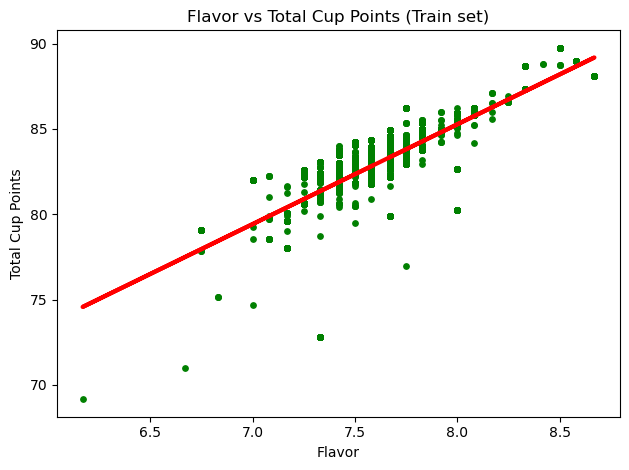

In [40]:
# Visualize the regression line (training set)
plt.scatter(X_train, y_train, color='green', s=15)
plt.plot(X_train, y_predicted_train, color='red', linewidth=3)
plt.title('Flavor vs Total Cup Points (Train set)')
plt.xlabel('Flavor')
plt.ylabel('Total Cup Points')
plt.tight_layout()
plt.savefig('C:/Users/Chase/anaconda_projects/Exercise_6_Coffee/A6_Coffee/04_Analysis/Visulazations/Outlier Check/regression_train_flavor_vs_cup_points.png')
plt.show()

##### Summary
The regression model trained on flavor scores yielded consistent performance across training and test sets. The slope of 5.85 indicates a strong positive relationship with total cup points. R² scores of 0.615 (train) and 0.588 (test) suggest the model explains over half the variance in cup scores. Predictions were generally within 1.5–2 points of actual values, confirming flavor as a reliable predictor of coffee quality.

### 4.2 Regression - Balance vs Total Cup Points

In [51]:
# Fit the Regression Model
regression = LinearRegression()
regression.fit(X_train, y_train)

LinearRegression()

In [52]:
# Predict on the Test Set
y_predicted = regression.predict(X_test)

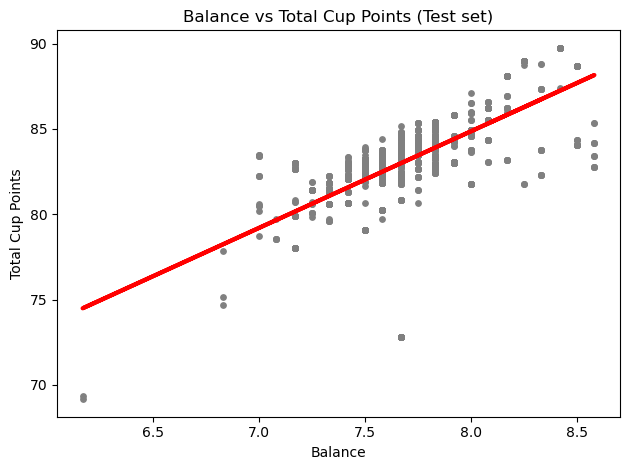

In [53]:
# Visualize the Regression Line (Test Set)
plt.scatter(X_test, y_test, color='gray', s=15)
plt.plot(X_test, y_predicted, color='red', linewidth=3)
plt.title('Balance vs Total Cup Points (Test set)')
plt.xlabel('Balance')
plt.ylabel('Total Cup Points')
plt.tight_layout()
plt.savefig('C:/Users/Chase/anaconda_projects/Exercise_6_Coffee/A6_Coffee/04_Analysis/Visulazations/Outlier Check/regression_test_balance_vs_cup_points.png')
plt.show()

In [54]:
# Evaluate Model Performance
rmse = mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)

print('Slope:', regression.coef_)
print('Mean squared error:', rmse)
print('R2 score:', r2)

Slope: [[5.67112885]]
Mean squared error: 4.062566862763181
R2 score: 0.4088564221049379


In [55]:
# Compare Actual vs Predicted
data = pd.DataFrame({
    'Actual': y_test.flatten(),
    'Predicted': y_predicted.flatten()
})
data.head(30)

,Actual,Predicted
0,87.33,86.742587
1,79.92,80.164077
2,83.67,82.999642
3,80.25,82.489240
4,84.25,83.907022
5,83.08,82.999642
6,82.75,88.160369
7,83.00,81.581860
8,82.75,81.581860
9,85.00,83.907022


##### Summary
A linear regression model was trained to predict total cup points using balance scores. The model yielded a slope of 5.67, indicating a positive relationship. However, the R2 score of 0.409 and RMSE of 4.06 suggest that balance is a weaker predictor than flavor, which previously achieved an R2 of 0.588 and RMSE of 2.83. This comparison highlights flavor as the more reliable standalone predictor of coffee quality.

## 5. Performance Improvement After Removing Outliers

### 5.1 Outlier Impact - Flavor vs Total Cup Points

In [41]:
# Filter Outliers from total_cup_points
df_clean = df_model[df_model['total_cup_points'] <= 90]

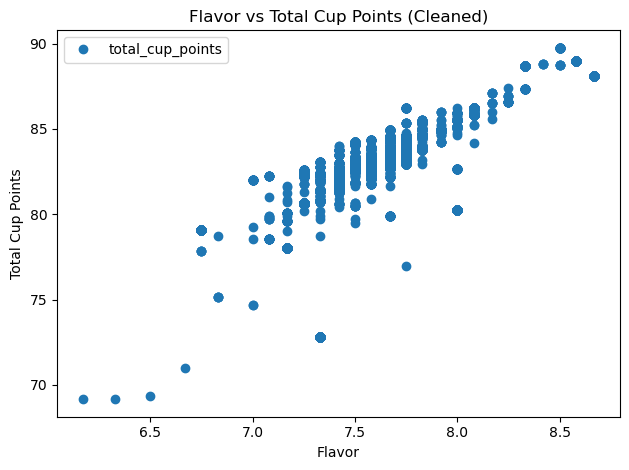

In [42]:
# Visualize the Cleaned Scatterplot
df_clean.plot(x='flavor', y='total_cup_points', style='o')
plt.title('Flavor vs Total Cup Points (Cleaned)')
plt.xlabel('Flavor')
plt.ylabel('Total Cup Points')
plt.tight_layout()
plt.savefig('C:/Users/Chase/anaconda_projects/Exercise_6_Coffee/A6_Coffee/04_Analysis/Visulazations/Outlier Check/scatterplot_flavor_vs_cup_points_cleaned.png')
plt.show()

In [43]:
# Reshape and Split Cleaned Data
X_2 = df_clean['flavor'].values.reshape(-1, 1)
y_2 = df_clean['total_cup_points'].values.reshape(-1, 1)

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.3, random_state=0)

In [44]:
# Fit and Evaluate the Cleaned Model
regression = LinearRegression()
regression.fit(X_train_2, y_train_2)

y_predicted_2 = regression.predict(X_test_2)

rmse_2 = mean_squared_error(y_test_2, y_predicted_2)
r2_2 = r2_score(y_test_2, y_predicted_2)

print('Slope:', regression.coef_)
print('Mean squared error:', rmse_2)
print('R2 score:', r2_2)

Slope: [[5.84671257]]
Mean squared error: 2.83086799243919
R2 score: 0.5880807651591715


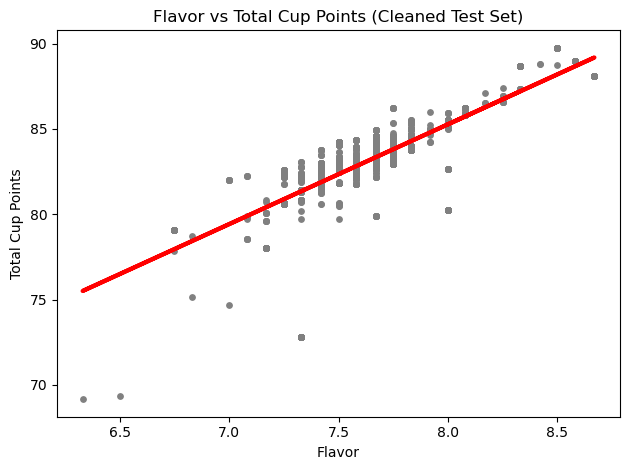

In [45]:
# Visualize the Regression Line (Cleaned Test Set)
plt.scatter(X_test_2, y_test_2, color='gray', s=15)
plt.plot(X_test_2, y_predicted_2, color='red', linewidth=3)
plt.title('Flavor vs Total Cup Points (Cleaned Test Set)')
plt.xlabel('Flavor')
plt.ylabel('Total Cup Points')
plt.tight_layout()
plt.savefig('C:/Users/Chase/anaconda_projects/Exercise_6_Coffee/A6_Coffee/04_Analysis/Visulazations/Outlier Check/regression_test_flavor_vs_cup_points_cleaned.png')
plt.show()

In [46]:
# Compare Actual vs Predicted (Cleaned)
data_cleaned = pd.DataFrame({
    'Actual': y_test_2.flatten(),
    'Predicted': y_predicted_2.flatten()
})
data_cleaned.head(30)

,Actual,Predicted
0,87.33,87.200781
1,79.92,83.341951
2,83.67,83.809688
3,80.25,85.271366
4,84.25,82.348010
5,83.08,83.341951
6,82.75,81.354069
7,83.00,82.815747
8,82.75,82.815747
9,85.00,84.803629


##### Summary
Outlier removal was tested to assess its impact on regression performance. A cleaned dataset was created by filtering out the outliers in total cup points ≤ 90. The resulting model showed no change in slope, mean squared error, or R2 score compared to the original. This suggests that the excluded values did not significantly distort the regression fit, and flavor remains a stable predictor of coffee quality.

### 5.2 Outlier Impact - Balance vs Total Cup Points

In [56]:
# Filter Outliers 
df_clean_balance = df_model[df_model['total_cup_points'] <= 90]

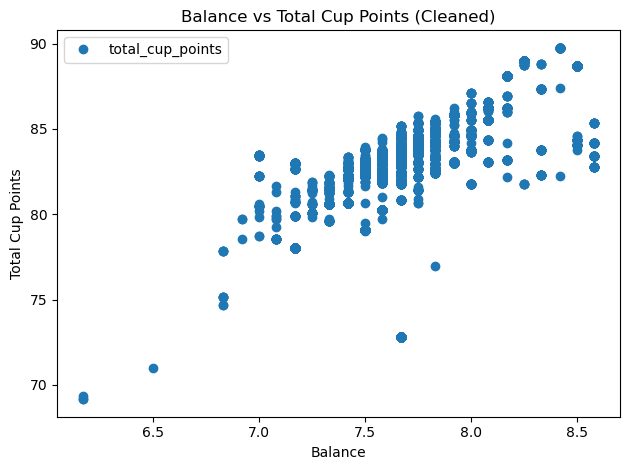

In [59]:
# Visualize the Cleaned Scatterplop
df_clean_balance.plot(x='balance', y='total_cup_points', style='o')
plt.title('Balance vs Total Cup Points (Cleaned)')
plt.xlabel('Balance')
plt.ylabel('Total Cup Points')
plt.tight_layout()
plt.savefig('C:/Users/Chase/anaconda_projects/Exercise_6_Coffee/A6_Coffee/04_Analysis/Visulazations/Outlier Check/scatterplot_balance_vs_cup_points_cleaned.png')
plt.show()

In [60]:
# Reshape and Split Cleaned Data
X_clean = df_clean_balance['balance'].values.reshape(-1, 1)
y_clean = df_clean_balance['total_cup_points'].values.reshape(-1, 1)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.3, random_state=0
)

In [61]:
# Fit and Evaluate the Cleaned Model
regression = LinearRegression()
regression.fit(X_train_c, y_train_c)

y_predicted_c = regression.predict(X_test_c)

rmse_c = mean_squared_error(y_test_c, y_predicted_c)
r2_c = r2_score(y_test_c, y_predicted_c)

print('Slope:', regression.coef_)
print('Mean squared error:', rmse_c)
print('R2 score:', r2_c)

Slope: [[5.67112885]]
Mean squared error: 4.062566862763181
R2 score: 0.4088564221049379


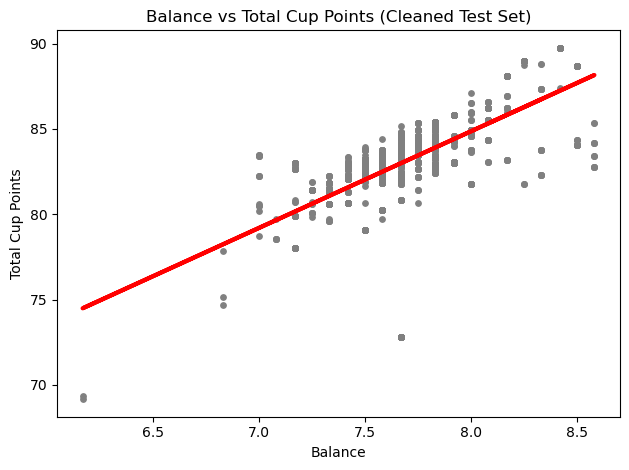

In [62]:
# isualize the Regression Line (Cleaned Test Set)
plt.scatter(X_test_c, y_test_c, color='gray', s=15)
plt.plot(X_test_c, y_predicted_c, color='red', linewidth=3)
plt.title('Balance vs Total Cup Points (Cleaned Test Set)')
plt.xlabel('Balance')
plt.ylabel('Total Cup Points')
plt.tight_layout()
plt.savefig('C:/Users/Chase/anaconda_projects/Exercise_6_Coffee/A6_Coffee/04_Analysis/Visulazations/Outlier Check/regression_test_balance_vs_cup_points_cleaned.png')
plt.show()

In [63]:
# Compare Actual vs Predicted (Cleaned)
data_cleaned = pd.DataFrame({
    'Actual': y_test_c.flatten(),
    'Predicted': y_predicted_c.flatten()
})
data_cleaned.head(30)

,Actual,Predicted
0,87.33,86.742587
1,79.92,80.164077
2,83.67,82.999642
3,80.25,82.489240
4,84.25,83.907022
5,83.08,82.999642
6,82.75,88.160369
7,83.00,81.581860
8,82.75,81.581860
9,85.00,83.907022


##### Summary
Outlier removal was tested to assess its impact on regression performance using balance as the predictor. A cleaned dataset was created by filtering total cup points ≤ 90. The resulting model showed no change in slope, mean squared error, or R2 score compared to the original. This suggests that the excluded values did not significantly distort the regression fit, and balance remains a stable but less powerful predictor of coffee quality than flavor.